In [1]:
from utils import format_bambi_ppc, plot_ppc, extract_rnp_precision, get_data
import bambi
import numpy as np
import os.path as op


bids_folder = '/Users/mrenke/data/ds-stressrisk'

target_folder = op.join(bids_folder, 'derivatives', 'cogmodels')
df = get_data()
df['x'] = df['log(risky/safe)']

/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
df.choice == 1

subject  run  trial_nr
1        1    1            True
              2            True
              3           False
              4            True
              5           False
                          ...  
61       6    116         False
              117         False
              118          True
              119          True
              120          True
Name: choice, Length: 11891, dtype: bool

In [23]:
df.loc[df.choice == 1, 'ev_choice'] = df.loc[df.choice == 1, 'p1'] * df.loc[df.choice == 1, 'n1']
df.loc[df.choice == 2, 'ev_choice'] = df.loc[df.choice == 2, 'p2'] * df.loc[df.choice == 2, 'n2']


/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_60179/1969353236.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.catplot(df.groupby(['subject', 'group', 'session']).mean().reset_index(), hue='group', y='ev_choice', x='session',


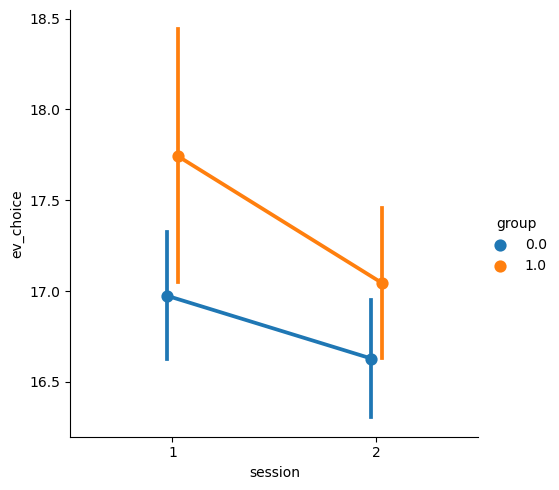

In [24]:
import seaborn as sns
sns.catplot(df.groupby(['subject', 'group', 'session']).mean().reset_index(), hue='group', y='ev_choice', x='session', 
            kind='point', errorbar='se', dodge=True)

In [25]:
import pingouin

pingouin

ModuleNotFoundError: No module named 'pingouin'

In [2]:
# 3. get parameters from trace

import arviz as az

n_model = 1
if n_model == 1:
    formulae = 'chose_risky ~ x*session*group + (x*session|subject)' # 1
elif n_model == 2:
    formulae = 'chose_risky ~ x*session:group + (x*session|subject)' # no main effect of group # 2
elif n_model == 3:
    formulae = 'chose_risky ~ x*session + x*session:group + (x*session|subject)' # 3
elif n_model == 4:
    formulae = 'chose_risky ~ x*risky_first*n_safe*session:group + (x*risky_first*n_safe*session|subject)' # 3

    

model = bambi.Model(formulae, link='probit', family='bernoulli', data=df.reset_index())

traces= az.from_netcdf(op.join(target_folder, f'bambi-RNP-fit_trace_model{n_model}.netcdf'))
intercept, gamma = extract_rnp_precision(traces, model, df, True)
rnp = np.clip(np.exp(intercept/gamma), 0, 1)

In [3]:
ppc = format_bambi_ppc(traces, model, df)

/Users/mrenke/git/stress_risk/stress_risk/behavior/utils.py:154: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ppc = ppc.groupby(['subject']+groupby).mean()
/Users/mrenke/git/stress_risk/stress_risk/behavior/utils.py:96: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = pd.DataFrame(az.hdi(ppc.T.values), index=ppc.index,


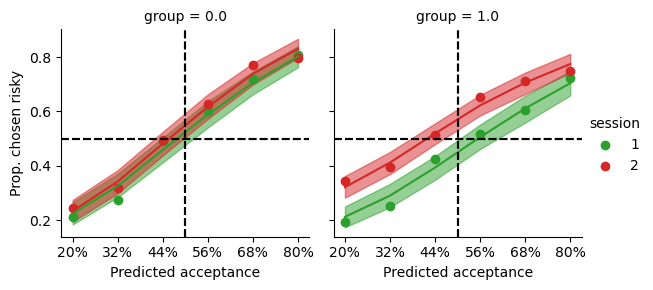

In [4]:
plot_ppc(df, ppc, level='group', plot_type=10)

/Users/mrenke/git/stress_risk/stress_risk/behavior/utils.py:154: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ppc = ppc.groupby(['subject']+groupby).mean()
/Users/mrenke/git/stress_risk/stress_risk/behavior/utils.py:96: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = pd.DataFrame(az.hdi(ppc.T.values), index=ppc.index,


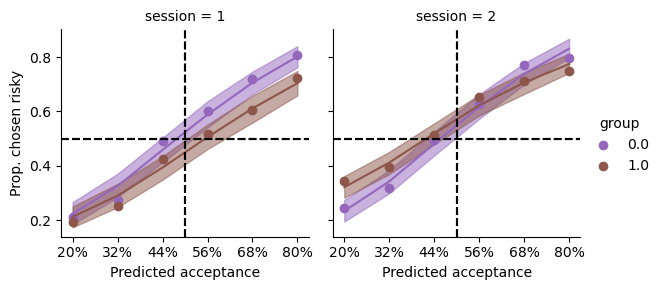

In [5]:
plot_ppc(df, ppc, level='group', plot_type=11)

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_60179/2248587879.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(traces.posterior['x:session'])


<AxesSubplot: xlabel='x:session', ylabel='Density'>

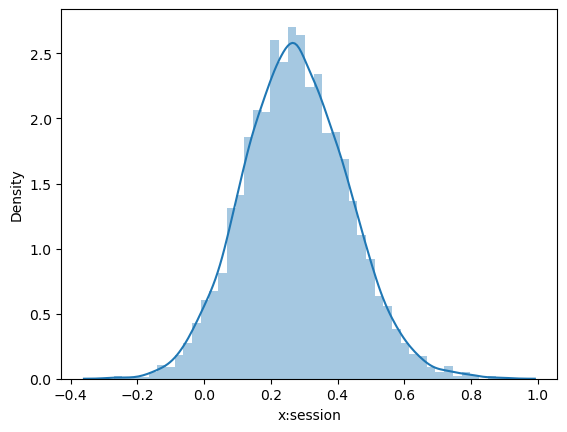

In [10]:
import seaborn as sns
sns.distplot(traces.posterior['x:session'])